# Lab Experiment 5: Comparative Analysis of Decision Tree & Random Forest Classifiers

Evaluation on the Wisconsin Diagnostic Breast Cancer (WDBC) dataset loaded using `sklearn.datasets.load_breast_cancer` (569 instances, 30 numerical attributes, binary classification: Malignant / Benign).


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

sns.set_style("whitegrid")
RANDOM_SEED = 42


## 1. Dataset Loading and Target Label Verification


In [2]:
cancer_data = load_breast_cancer()
feat_df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
target_series = pd.Series(cancer_data.target, name="diagnosis")  # 0=malignant, 1=benign
cls_labels = cancer_data.target_names

print("Shape:", feat_df.shape)
print("Missing values:", feat_df.isnull().sum().sum())
target_series.map({0: "malignant", 1: "benign"}).value_counts()


Shape: (569, 30)
Missing values: 0


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

## 2. Exploratory Data Analysis (EDA)


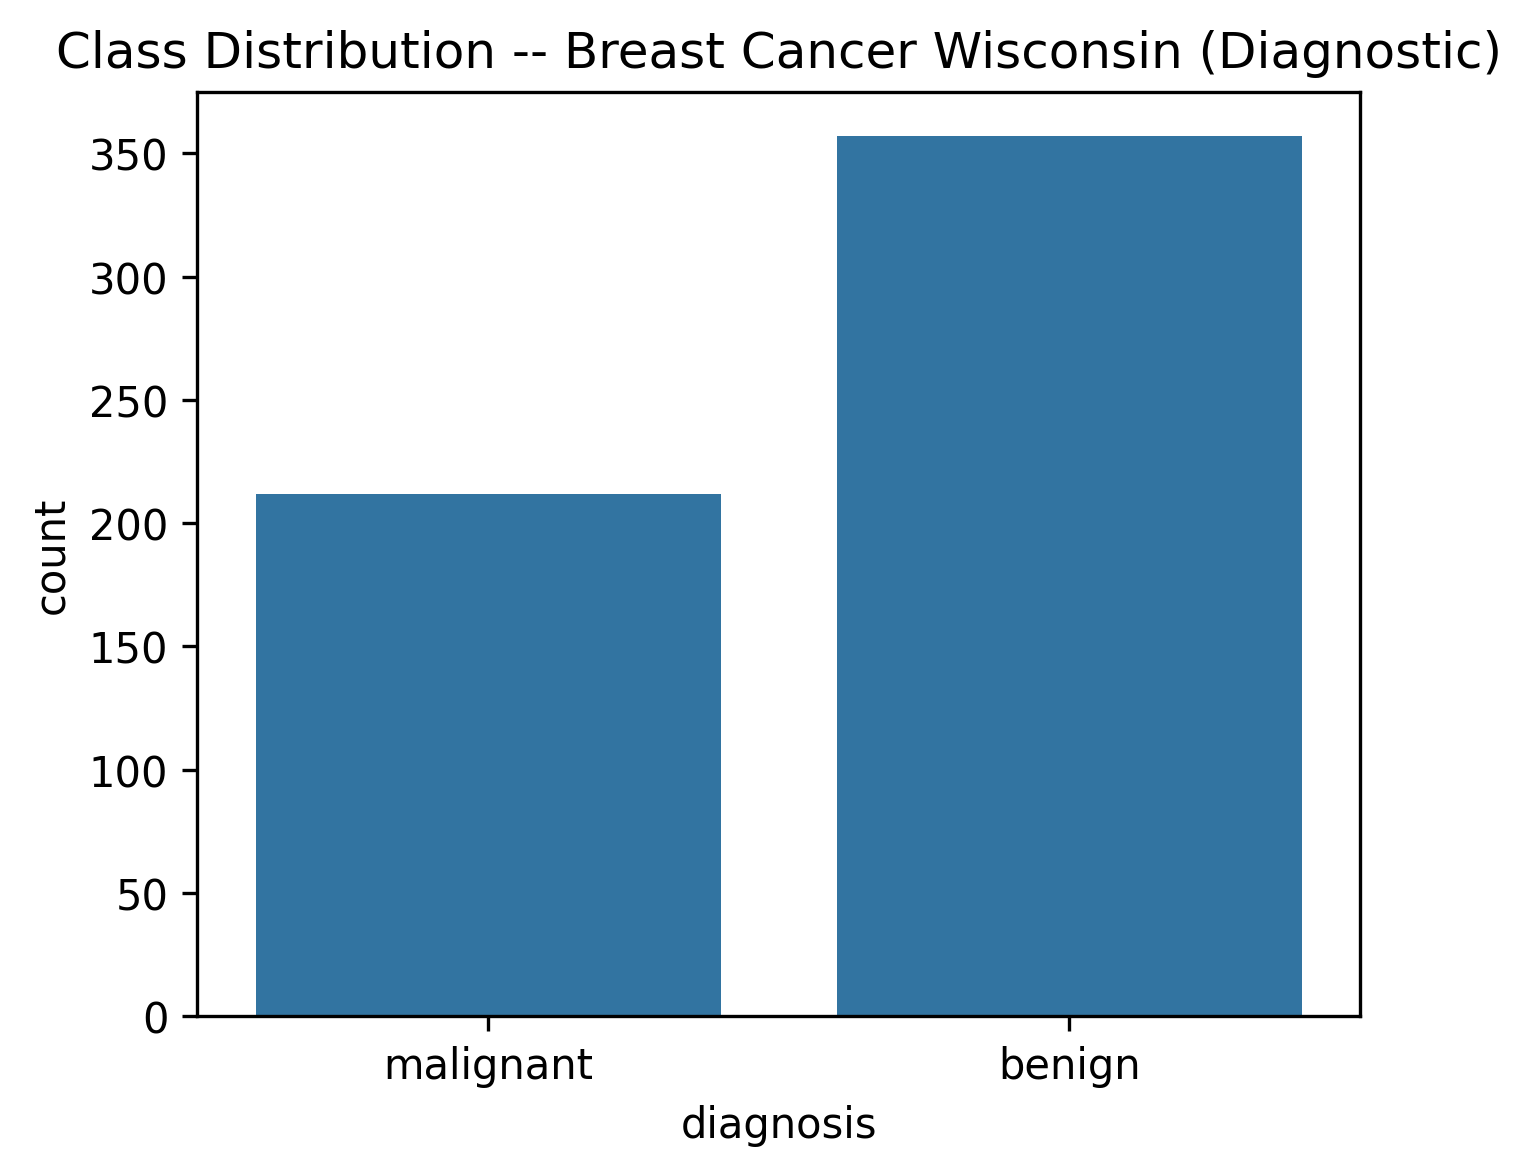

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=target_series.map({0: "malignant", 1: "benign"}), ax=ax)
ax.set_title("Class Distribution -- Breast Cancer Wisconsin (Diagnostic)")
plt.savefig("exp5_figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


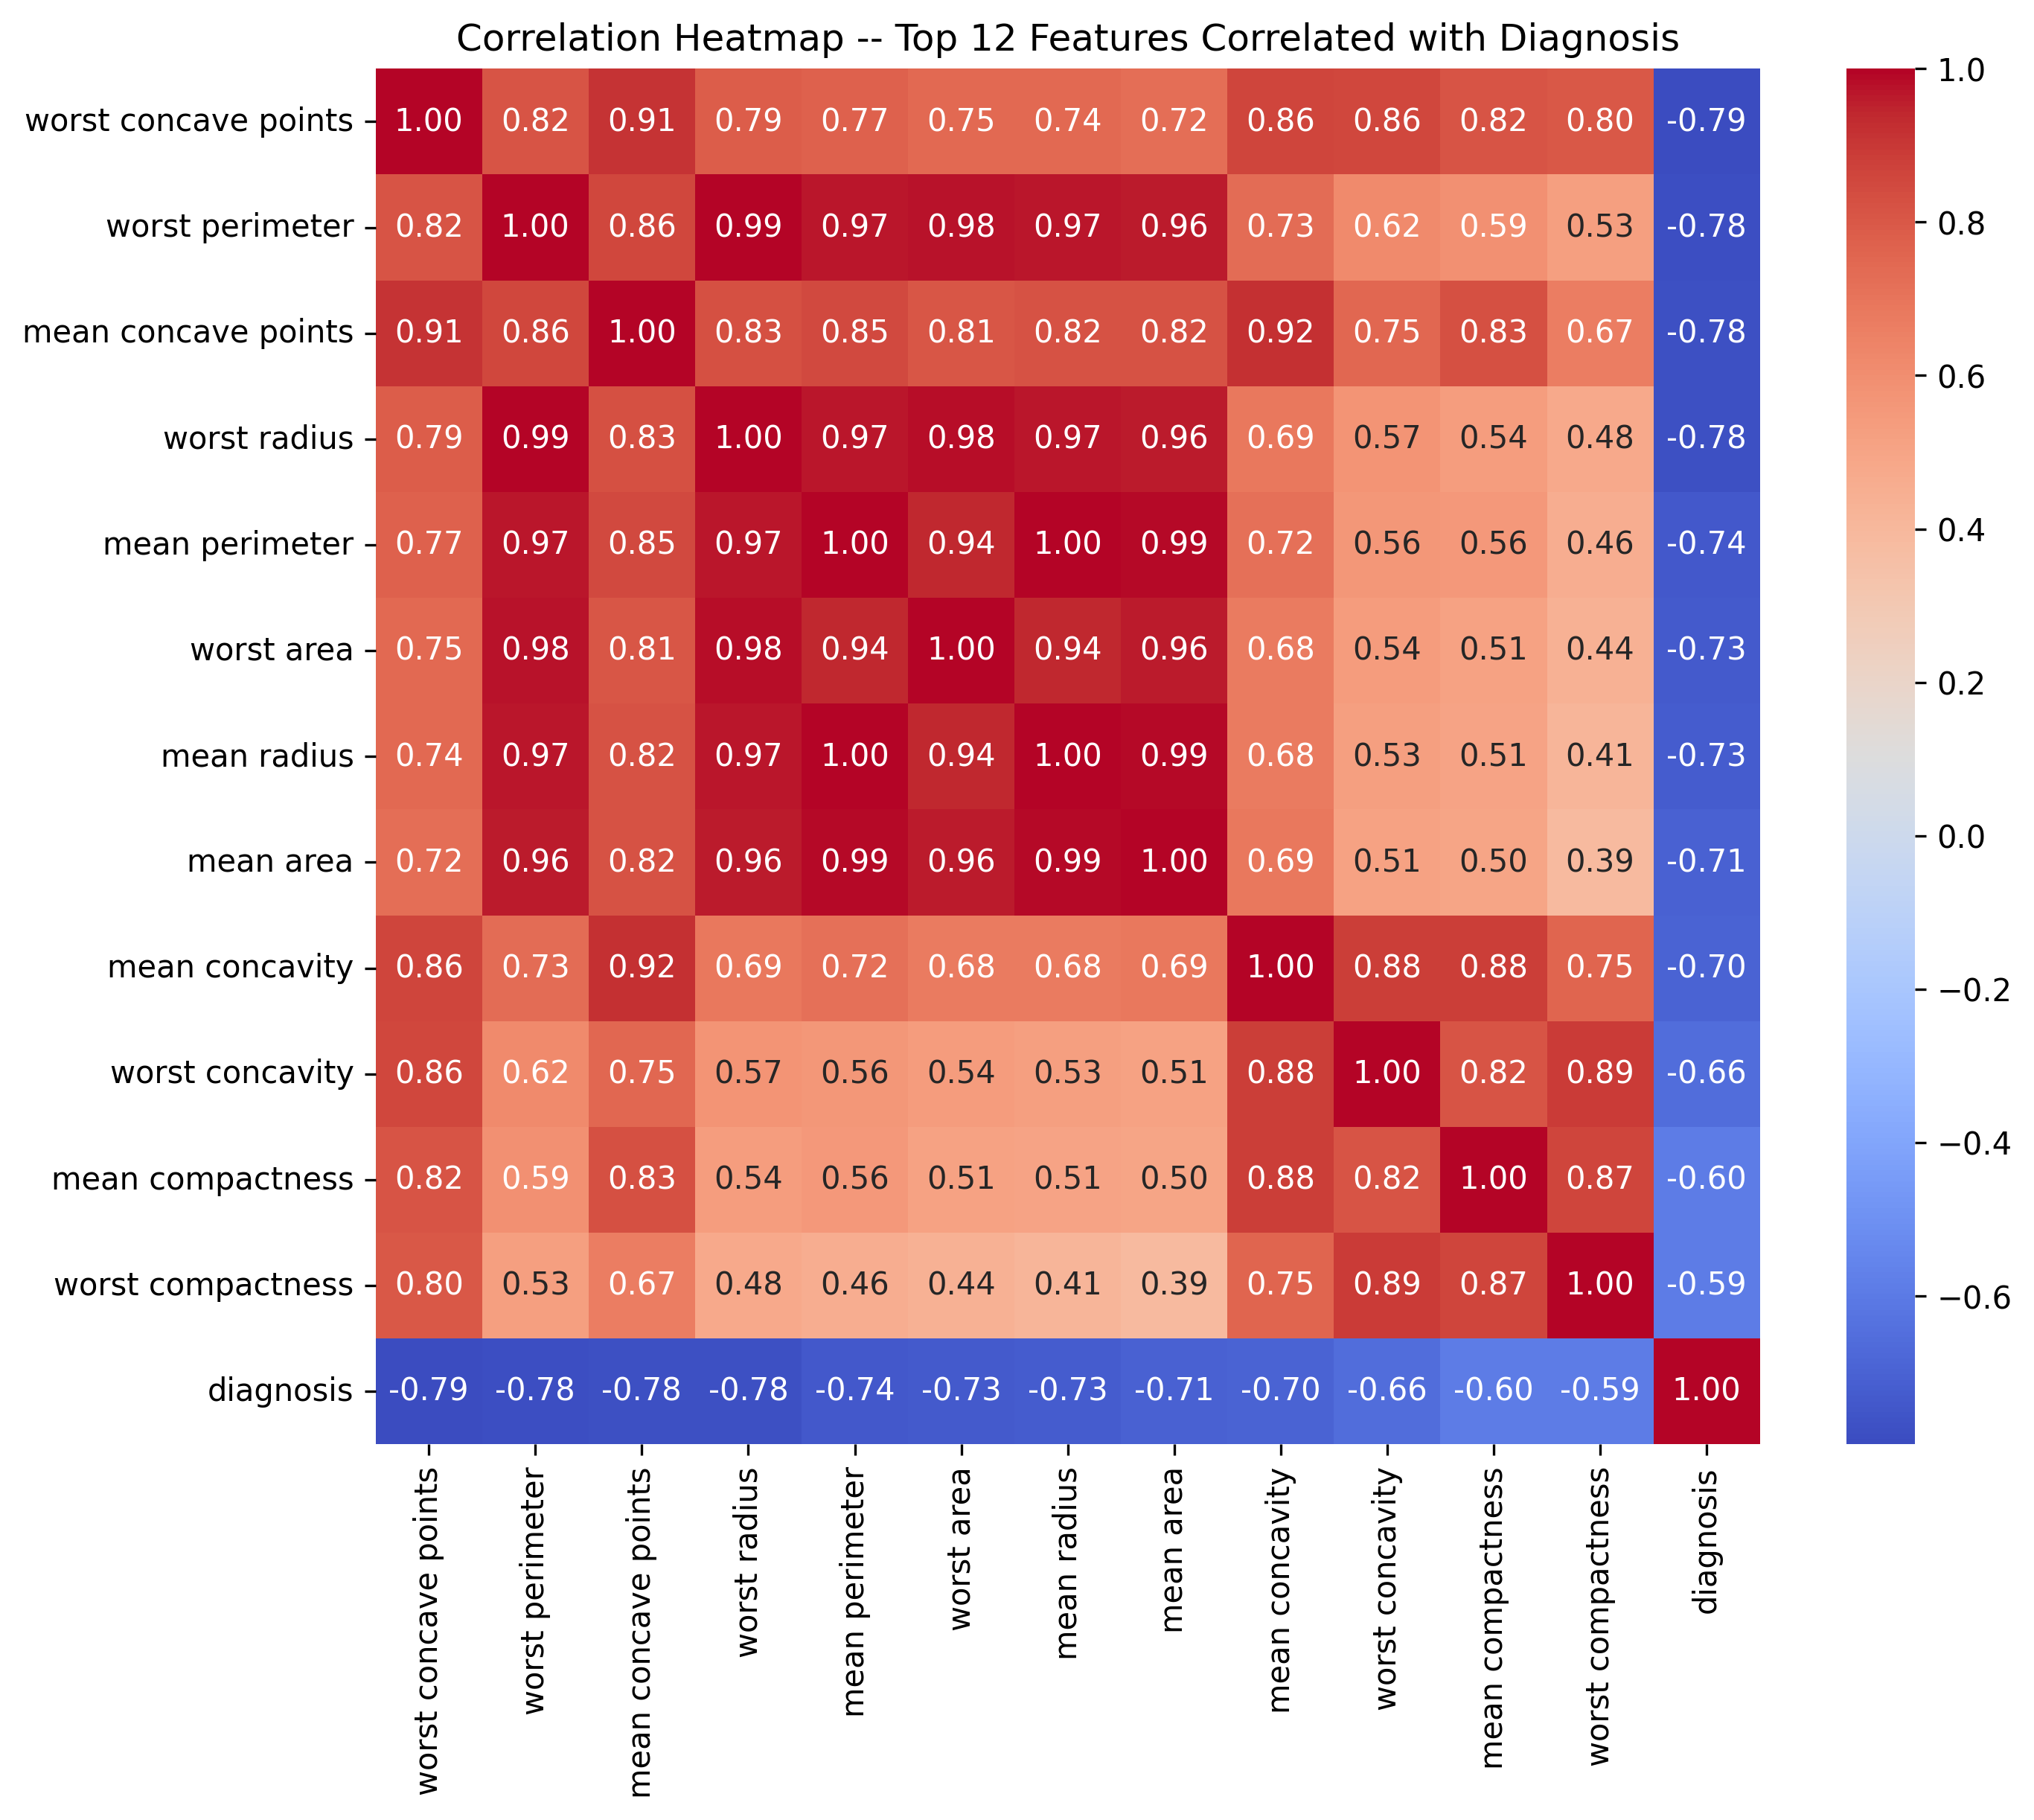

In [4]:
dominant_features = feat_df.corrwith(target_series).abs().sort_values(ascending=False).head(12).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(pd.concat([feat_df[dominant_features], target_series], axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap -- Top 12 Features Correlated with Diagnosis")
plt.savefig("exp5_figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 3. Stratified Train-Test Dataset Splitting (80:20)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(feat_df, target_series, test_size=0.2, stratify=target_series, random_state=RANDOM_SEED)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (455, 30)  Test: (114, 30)


In [6]:
def assess_classifier_performance(clf_model, train_x, train_y, test_x, test_y):
    t0 = time.time()
    clf_model.fit(train_x, train_y)
    t_train = time.time() - t0
    
    t0 = time.time()
    y_pred = clf_model.predict(test_x)
    t_pred = time.time() - t0
    
    y_prob = clf_model.predict_proba(test_x)[:, 1]
    
    metrics_dict = dict(
        Accuracy=accuracy_score(test_y, y_pred),
        Precision=precision_score(test_y, y_pred),
        Recall=recall_score(test_y, y_pred),
        F1=f1_score(test_y, y_pred),
        ROC_AUC=roc_auc_score(test_y, y_prob),
        TrainTime=t_train,
        PredictTime=t_pred,
    )
    return metrics_dict, y_pred, y_prob

cv_stratified_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


## 4. Train Baseline Decision Tree Classifier


In [7]:
tree_base = DecisionTreeClassifier(random_state=RANDOM_SEED)
tree_base_stats, tree_base_pred, tree_base_prob = assess_classifier_performance(
    tree_base, X_train, y_train, X_test, y_test
)
print("Baseline tree depth:", tree_base.get_depth())
tree_base_stats


Baseline tree depth: 7


{'Accuracy': 0.9122807017543859, 'Precision': 0.9558823529411765, 'Recall': 0.9027777777777778, 'F1': 0.9285714285714286, 'ROC_AUC': 0.9156746031746031, 'TrainTime': 0.017419099807739258, 'PredictTime': 0.0022640228271484375}

## 5-6. Decision Tree Hyperparameter Optimization (5-Fold Grid Search)


In [8]:
dt_hyperparams = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
dt_search = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_SEED), param_grid=dt_hyperparams,
                        cv=cv_stratified_folds, scoring="accuracy", n_jobs=-1)
dt_search.fit(X_train, y_train)
print("Best params:", dt_search.best_params_)
print("Best CV accuracy:", round(dt_search.best_score_, 4))


Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV accuracy: 0.9385


In [9]:
best_tree_model = dt_search.best_estimator_
best_dt_stats, best_dt_pred, best_dt_prob = assess_classifier_performance(best_tree_model, X_train, y_train, X_test, y_test)
print("Best tree depth:", best_tree_model.get_depth())
best_dt_stats


Best tree depth: 5


{'Accuracy': 0.9035087719298246, 'Precision': 0.9420289855072463, 'Recall': 0.9027777777777778, 'F1': 0.9219858156028369, 'ROC_AUC': 0.9358465608465609, 'TrainTime': 0.018689393997192383, 'PredictTime': 0.0032939910888671875}

## 7-9. Random Forest Baseline and Hyperparameter Tuning


In [10]:
forest_base = RandomForestClassifier(random_state=RANDOM_SEED)
forest_base_stats, forest_base_pred, forest_base_prob = assess_classifier_performance(
    forest_base, X_train, y_train, X_test, y_test)
forest_base_stats


{'Accuracy': 0.956140350877193, 'Precision': 0.958904109589041, 'Recall': 0.9722222222222222, 'F1': 0.9655172413793104, 'ROC_AUC': 0.9937169312169312, 'TrainTime': 0.2767486572265625, 'PredictTime': 0.015088796615600586}

In [11]:
rf_hyperparams = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}
rf_search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_SEED), param_grid=rf_hyperparams,
                        cv=cv_stratified_folds, scoring="accuracy", n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("Best CV accuracy:", round(rf_search.best_score_, 4))


Best params: {'bootstrap': True, 'max_depth': 10, 'max_features': 'log2', 'n_estimators': 100}
Best CV accuracy: 0.9648


In [12]:
best_forest_model = rf_search.best_estimator_
best_rf_stats, best_rf_pred, best_rf_prob = assess_classifier_performance(best_forest_model, X_train, y_train, X_test, y_test)
best_rf_stats


{'Accuracy': 0.956140350877193, 'Precision': 0.958904109589041, 'Recall': 0.9722222222222222, 'F1': 0.9655172413793104, 'ROC_AUC': 0.9923941798941799, 'TrainTime': 0.19362187385559082, 'PredictTime': 0.011576414108276367}

## 10. 5-Fold Cross-Validation Score Comparison


In [13]:
tree_cv_results = cross_val_score(DecisionTreeClassifier(**dt_search.best_params_, random_state=RANDOM_SEED),
                                feat_df, target_series, cv=cv_stratified_folds, scoring="accuracy")
forest_cv_results = cross_val_score(RandomForestClassifier(**rf_search.best_params_, random_state=RANDOM_SEED),
                                feat_df, target_series, cv=cv_stratified_folds, scoring="accuracy")

print("DT folds:", tree_cv_results.round(4), " avg:", round(tree_cv_results.mean(),4))
print("RF folds:", forest_cv_results.round(4), " avg:", round(forest_cv_results.mean(),4))


DT folds: [0.9211 0.8947 0.9386 0.9298 0.9381]  avg: 0.9245
RF folds: [0.9649 0.9561 0.9561 0.9561 0.9646]  avg: 0.9596


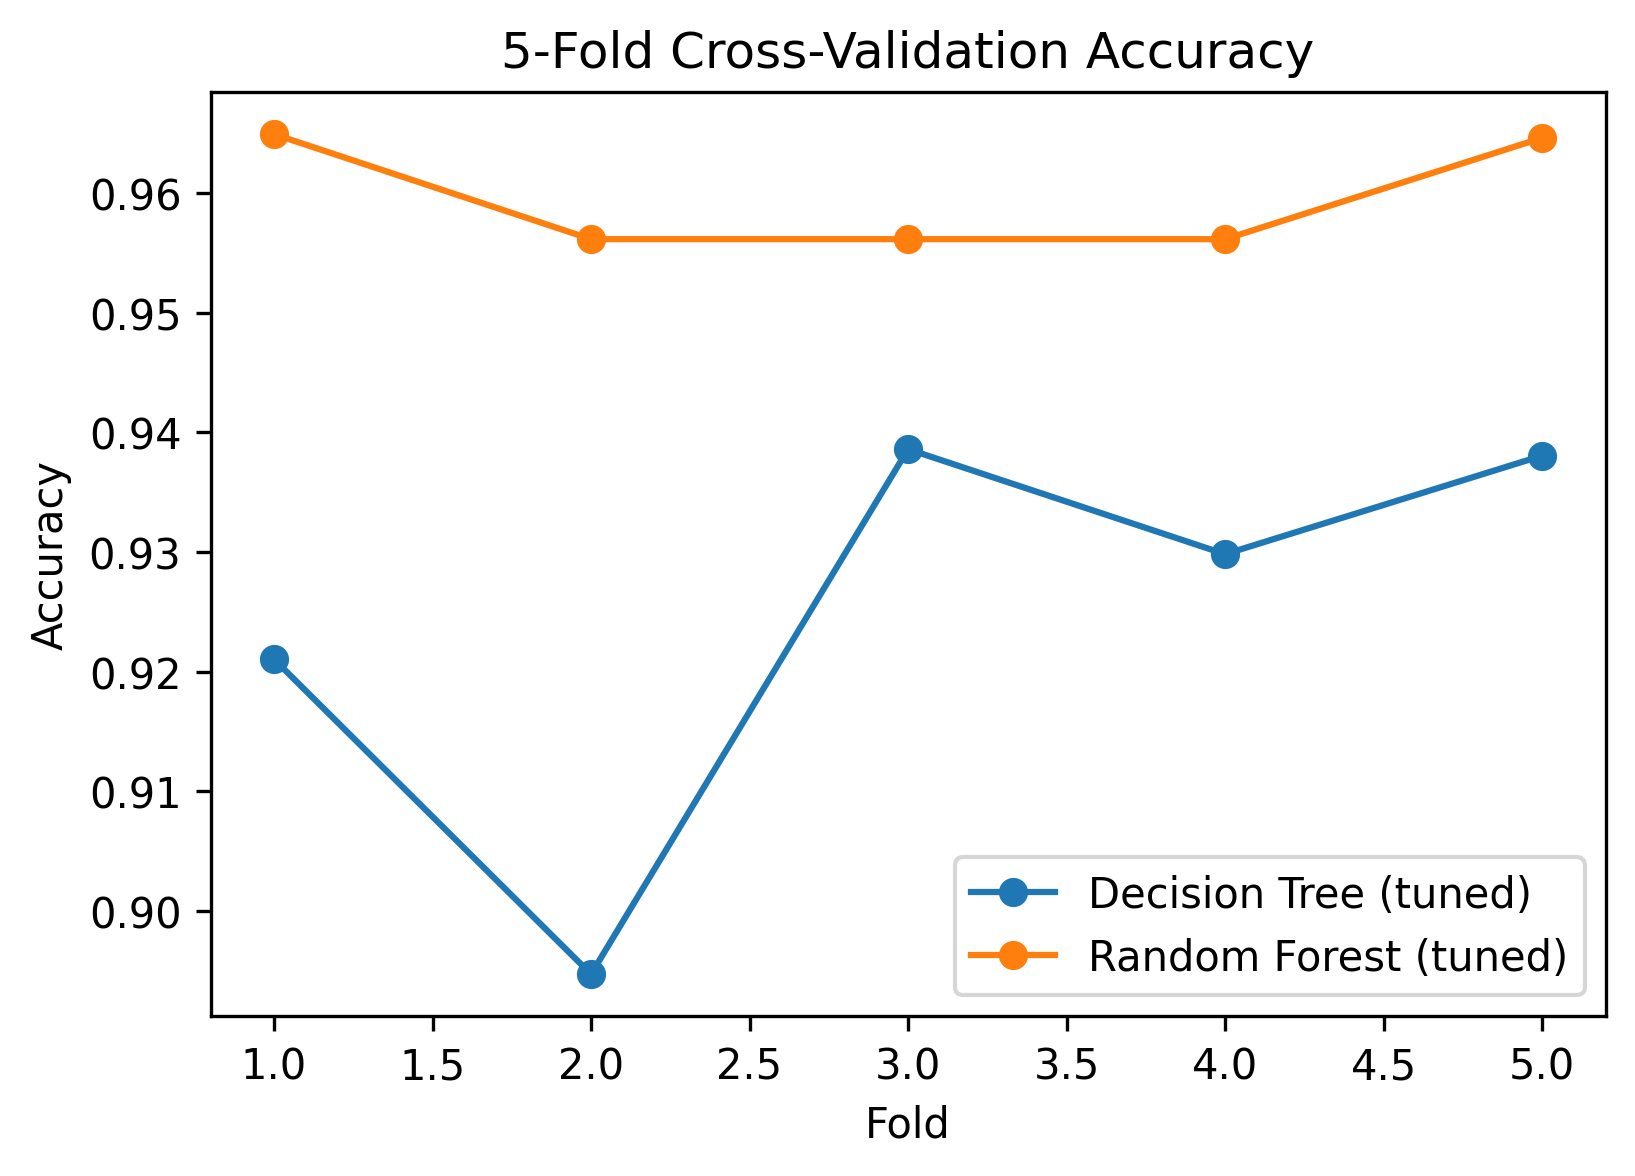

In [14]:
plt.figure(figsize=(6,4))
fold_nums = list(range(1,6))
plt.plot(fold_nums, tree_cv_results, "o-", label="Decision Tree (tuned)")
plt.plot(fold_nums, forest_cv_results, "o-", label="Random Forest (tuned)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.legend()
plt.savefig("exp5_figures/cv_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Overfitting Evaluation: max_depth (Tree) & n_estimators (Forest)


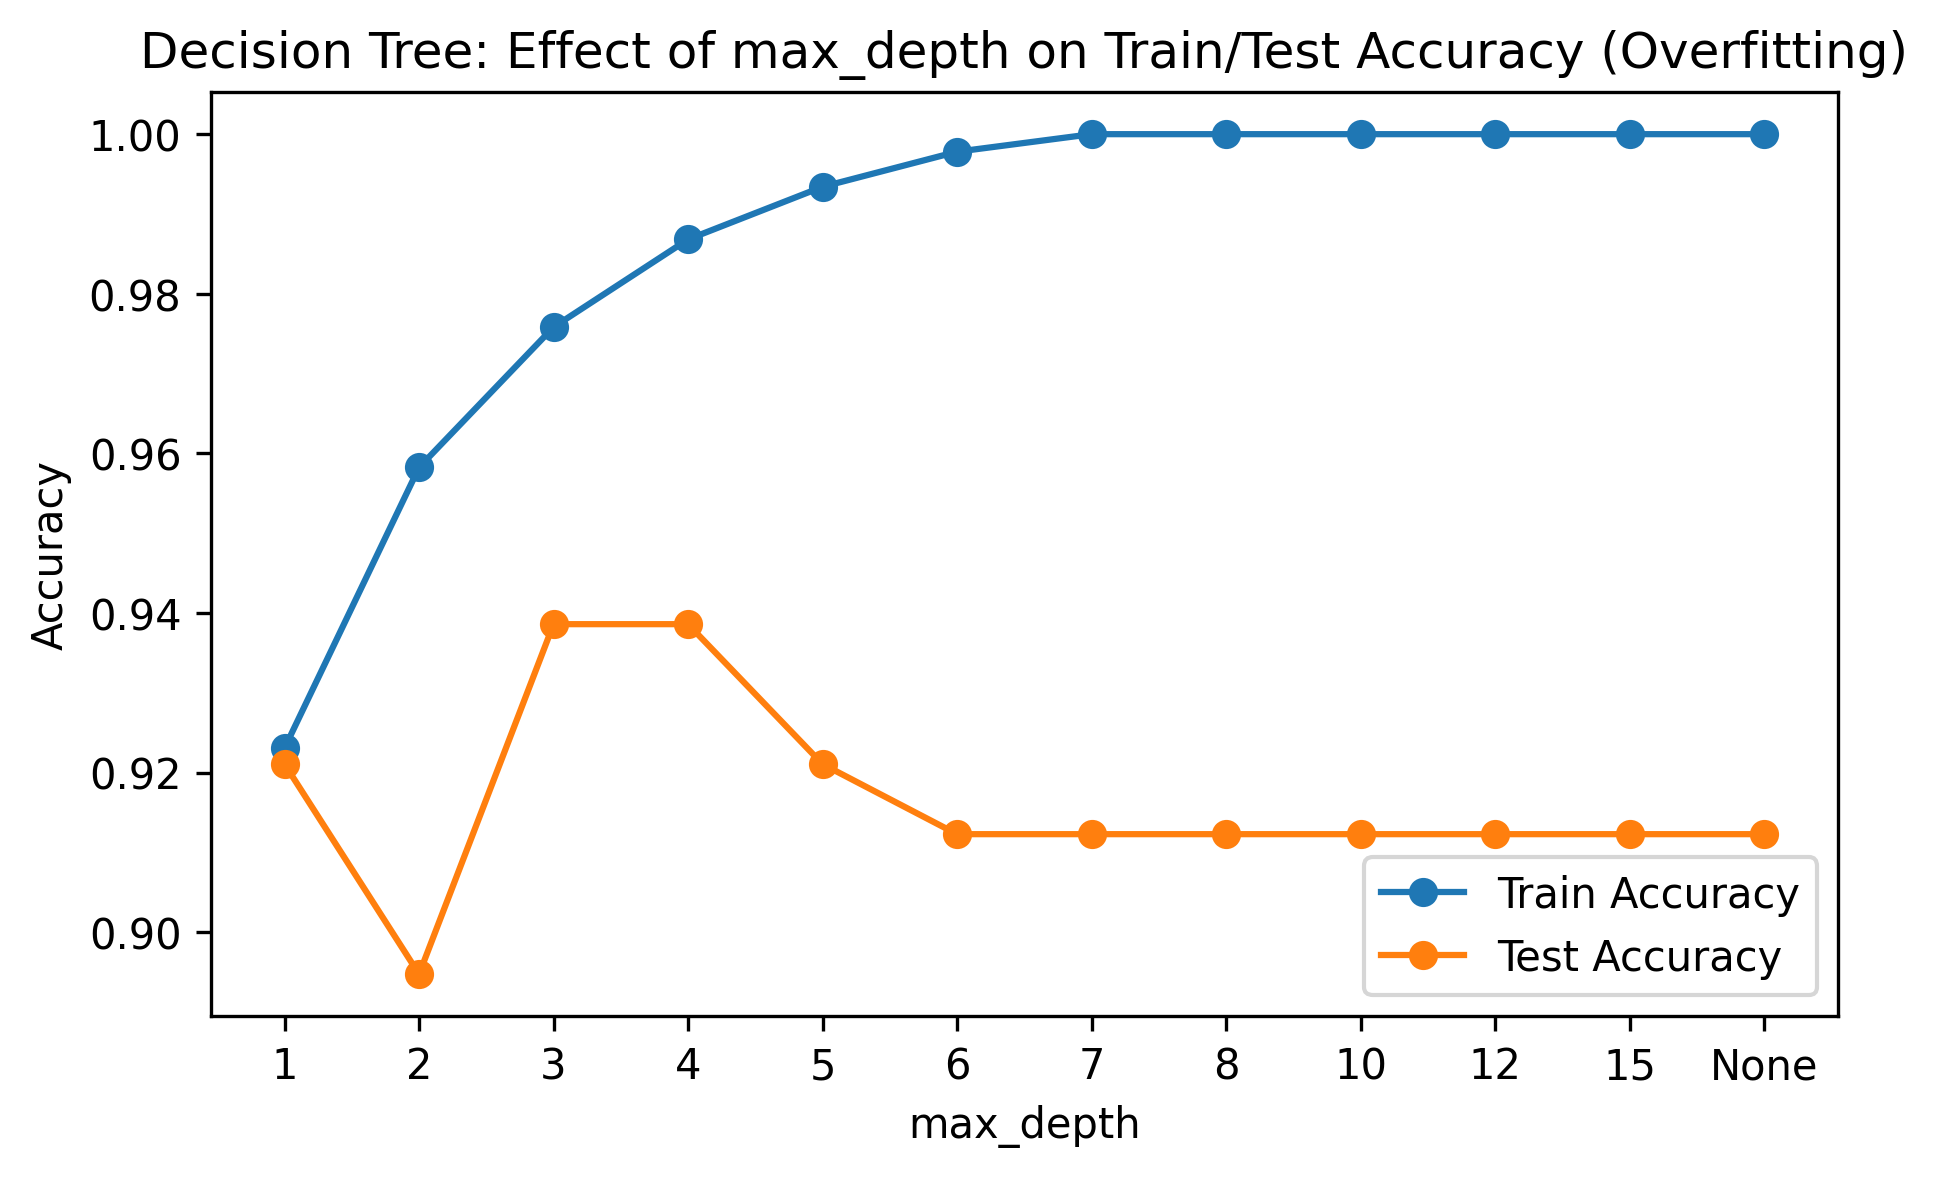

In [15]:
depth_range = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, None]
depth_acc_records = {}
for d in depth_range:
    clf = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_SEED)
    clf.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    depth_acc_records[str(d)] = (tr_acc, te_acc)

d_labels = [str(d) for d in depth_range]
plt.figure(figsize=(7,4))
plt.plot(d_labels, [depth_acc_records[d][0] for d in d_labels], "o-", label="Train Accuracy")
plt.plot(d_labels, [depth_acc_records[d][1] for d in d_labels], "o-", label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Effect of max_depth on Train/Test Accuracy (Overfitting)")
plt.legend()
plt.savefig("exp5_figures/depth_overfitting_curve.png", dpi=300, bbox_inches="tight")
plt.show()


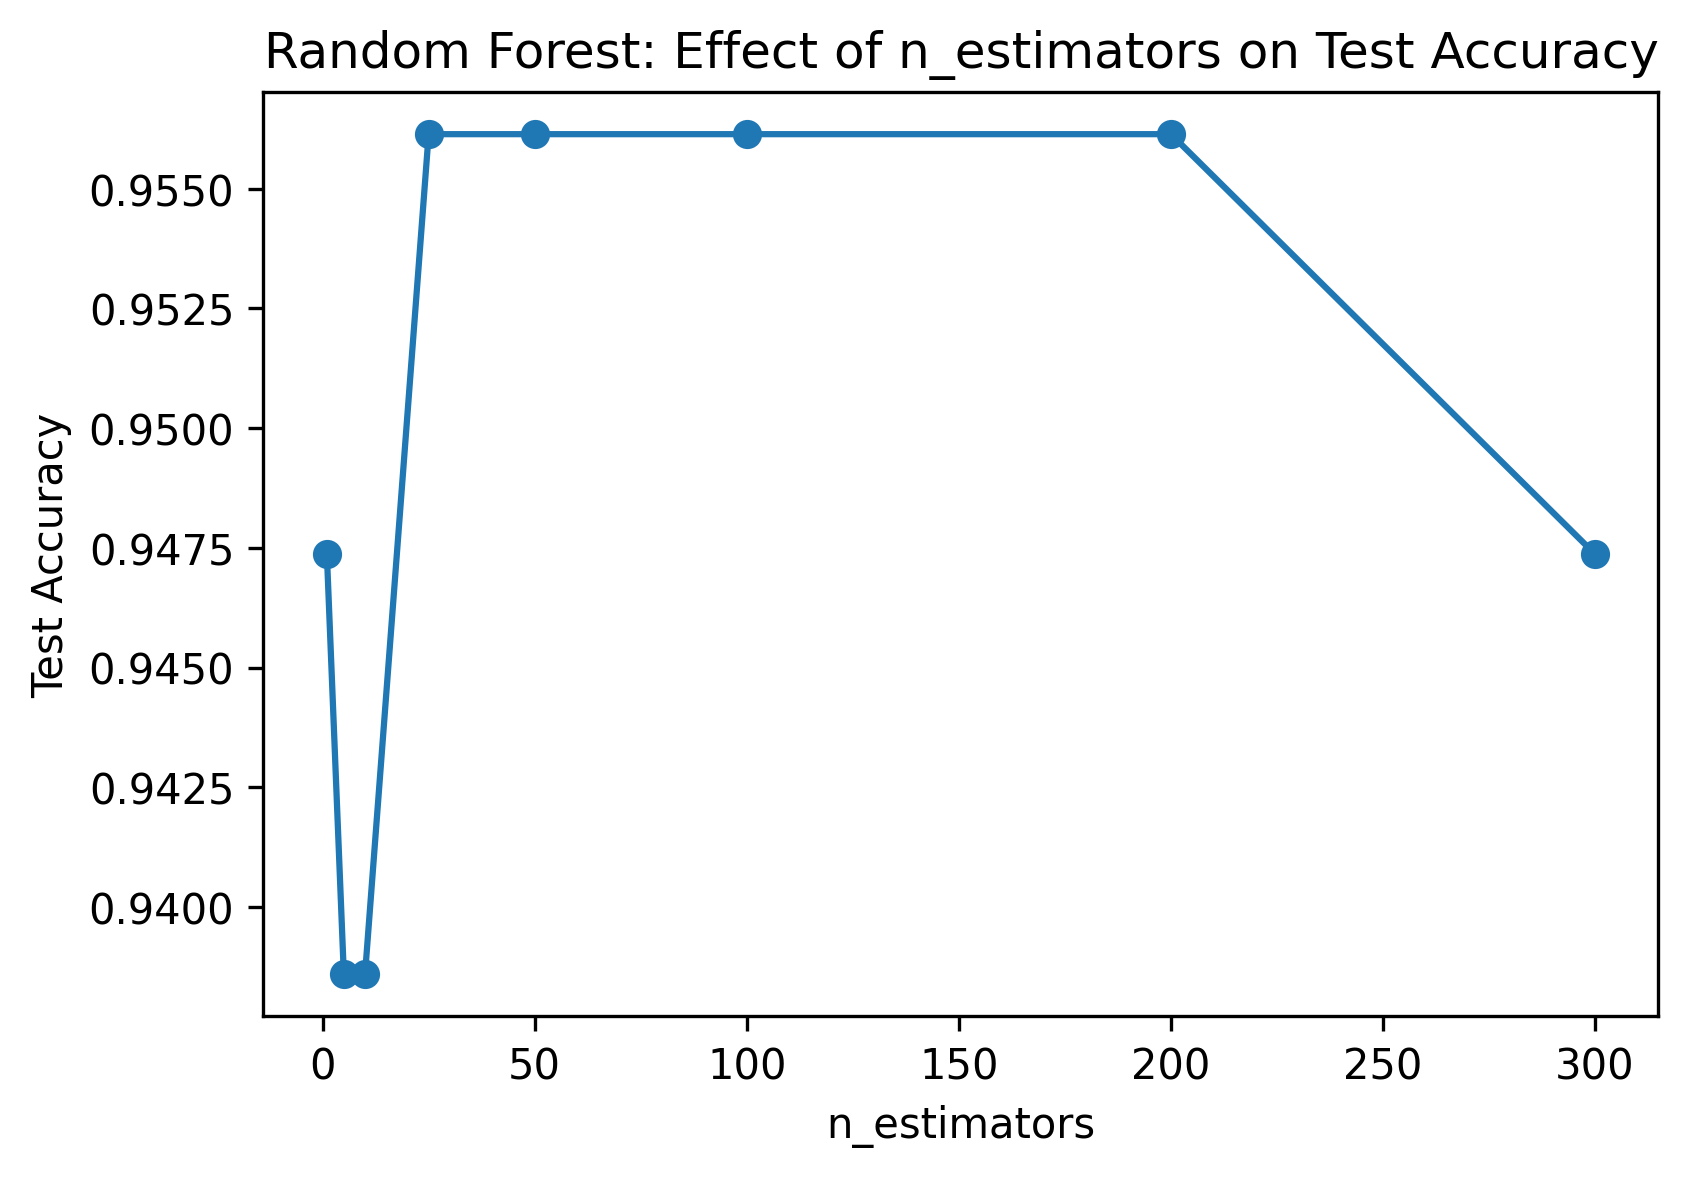

In [16]:
estimator_counts = [1, 5, 10, 25, 50, 100, 200, 300]
rf_acc_records = {}
for n in estimator_counts:
    rf_mod = RandomForestClassifier(n_estimators=n, random_state=RANDOM_SEED)
    rf_mod.fit(X_train, y_train)
    te_acc = accuracy_score(y_test, rf_mod.predict(X_test))
    rf_acc_records[n] = te_acc

plt.figure(figsize=(6,4))
plt.plot(list(rf_acc_records.keys()), list(rf_acc_records.values()), "o-")
plt.xlabel("n_estimators")
plt.ylabel("Test Accuracy")
plt.title("Random Forest: Effect of n_estimators on Test Accuracy")
plt.savefig("exp5_figures/n_estimators_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## Confusion Matrices and ROC-AUC Analysis


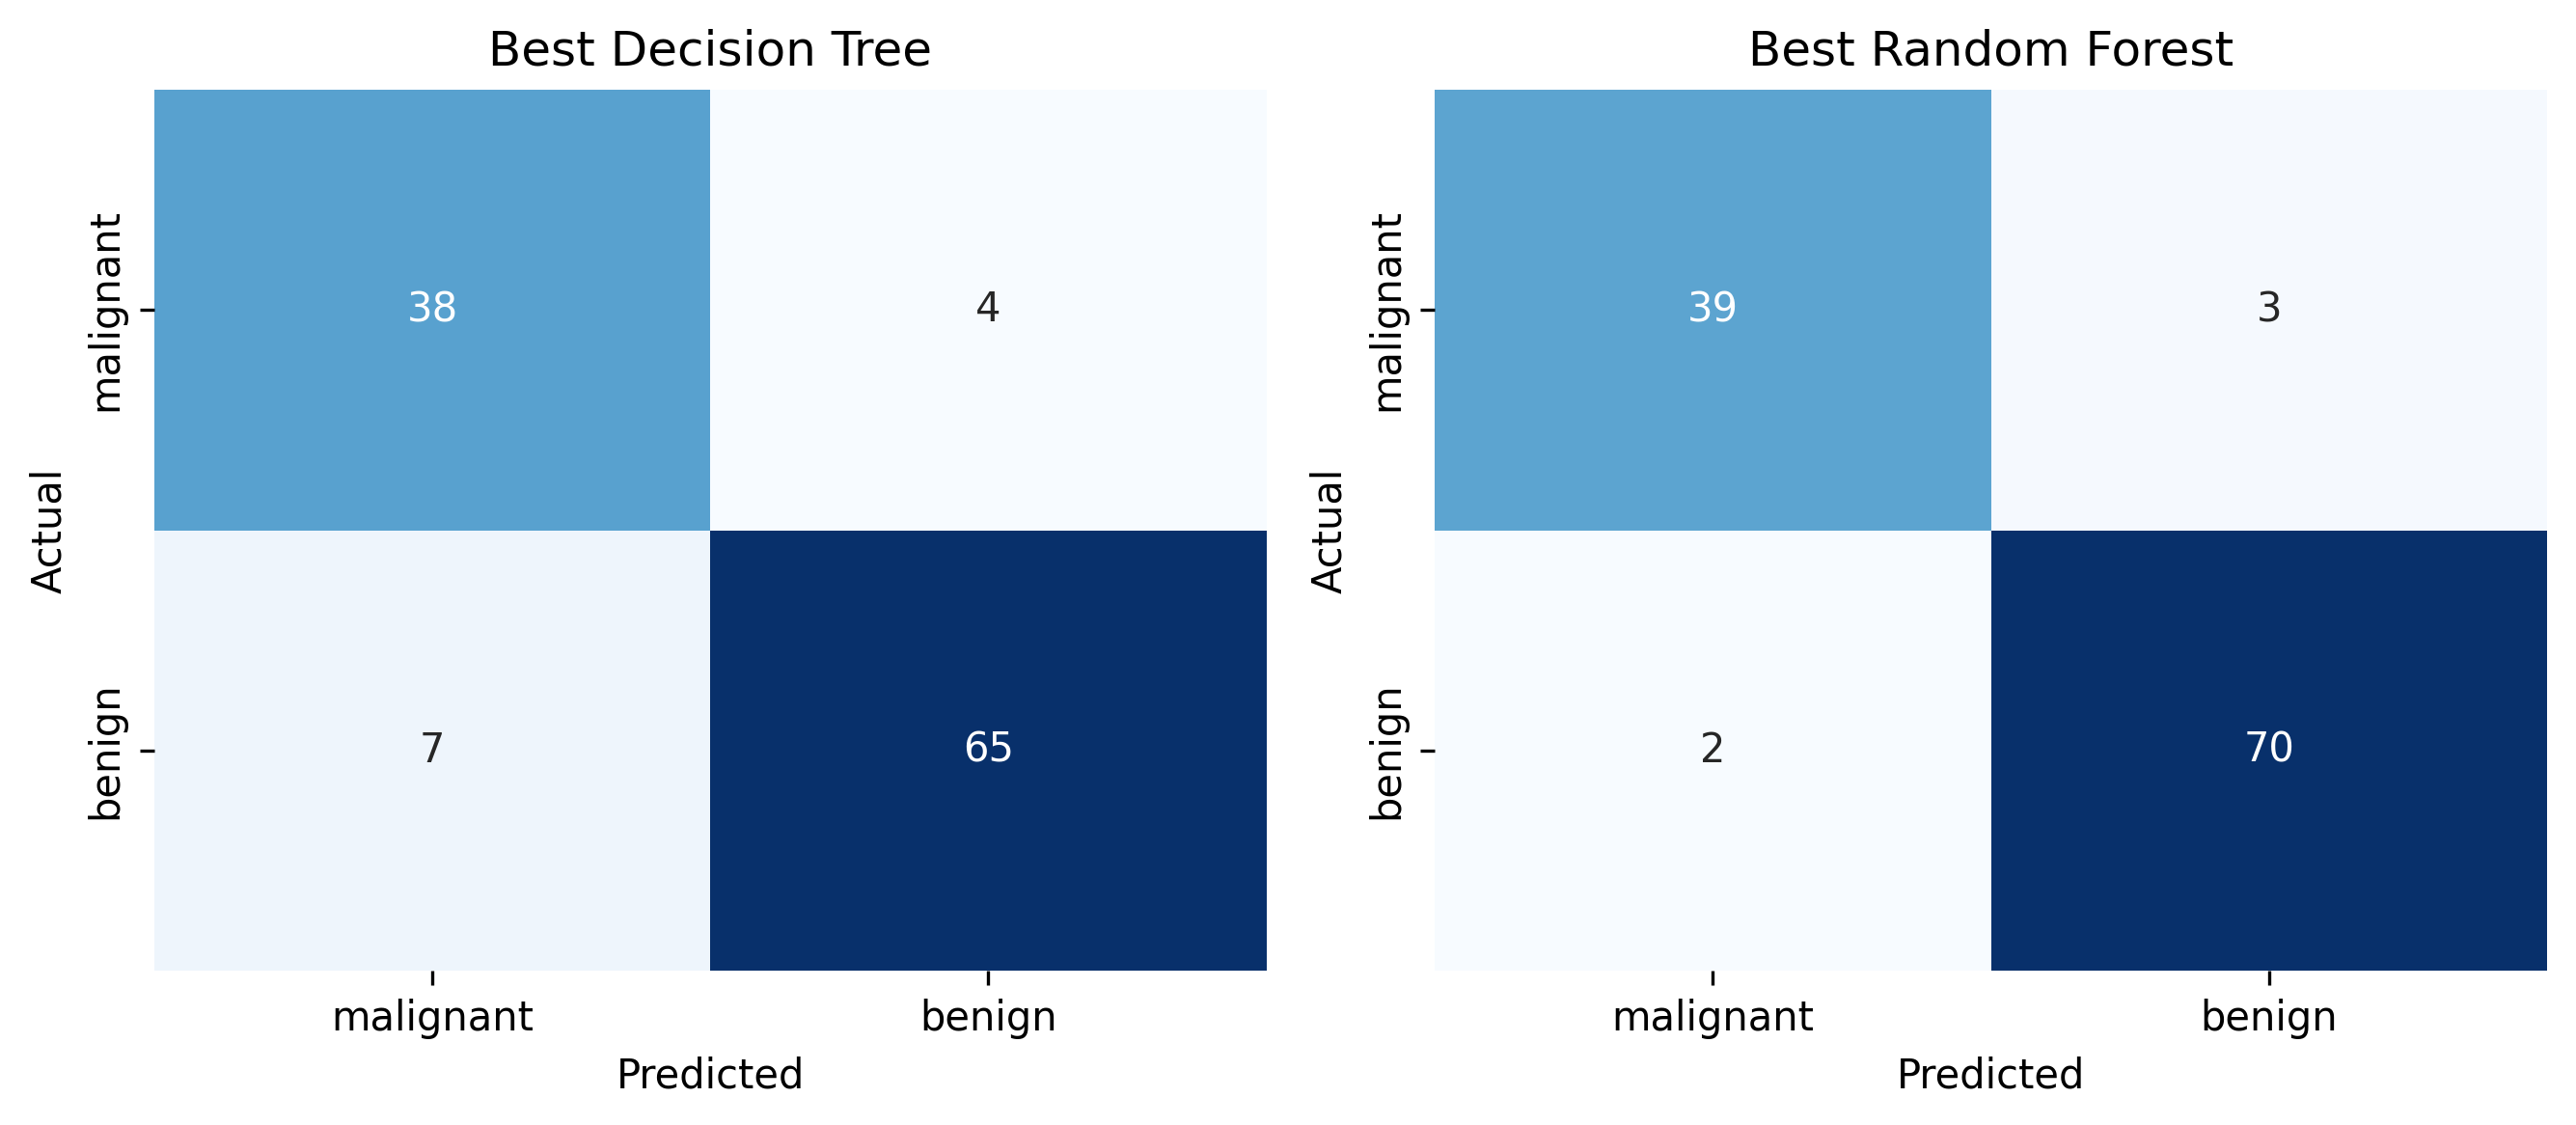

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9,4))
for ax, (m_title, p_vals) in zip(axes, [("Best Decision Tree", best_dt_pred), ("Best Random Forest", best_rf_pred)]):
    matrix_cm = confusion_matrix(y_test, p_vals)
    sns.heatmap(matrix_cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["malignant","benign"], yticklabels=["malignant","benign"])
    ax.set_title(m_title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("exp5_figures/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()


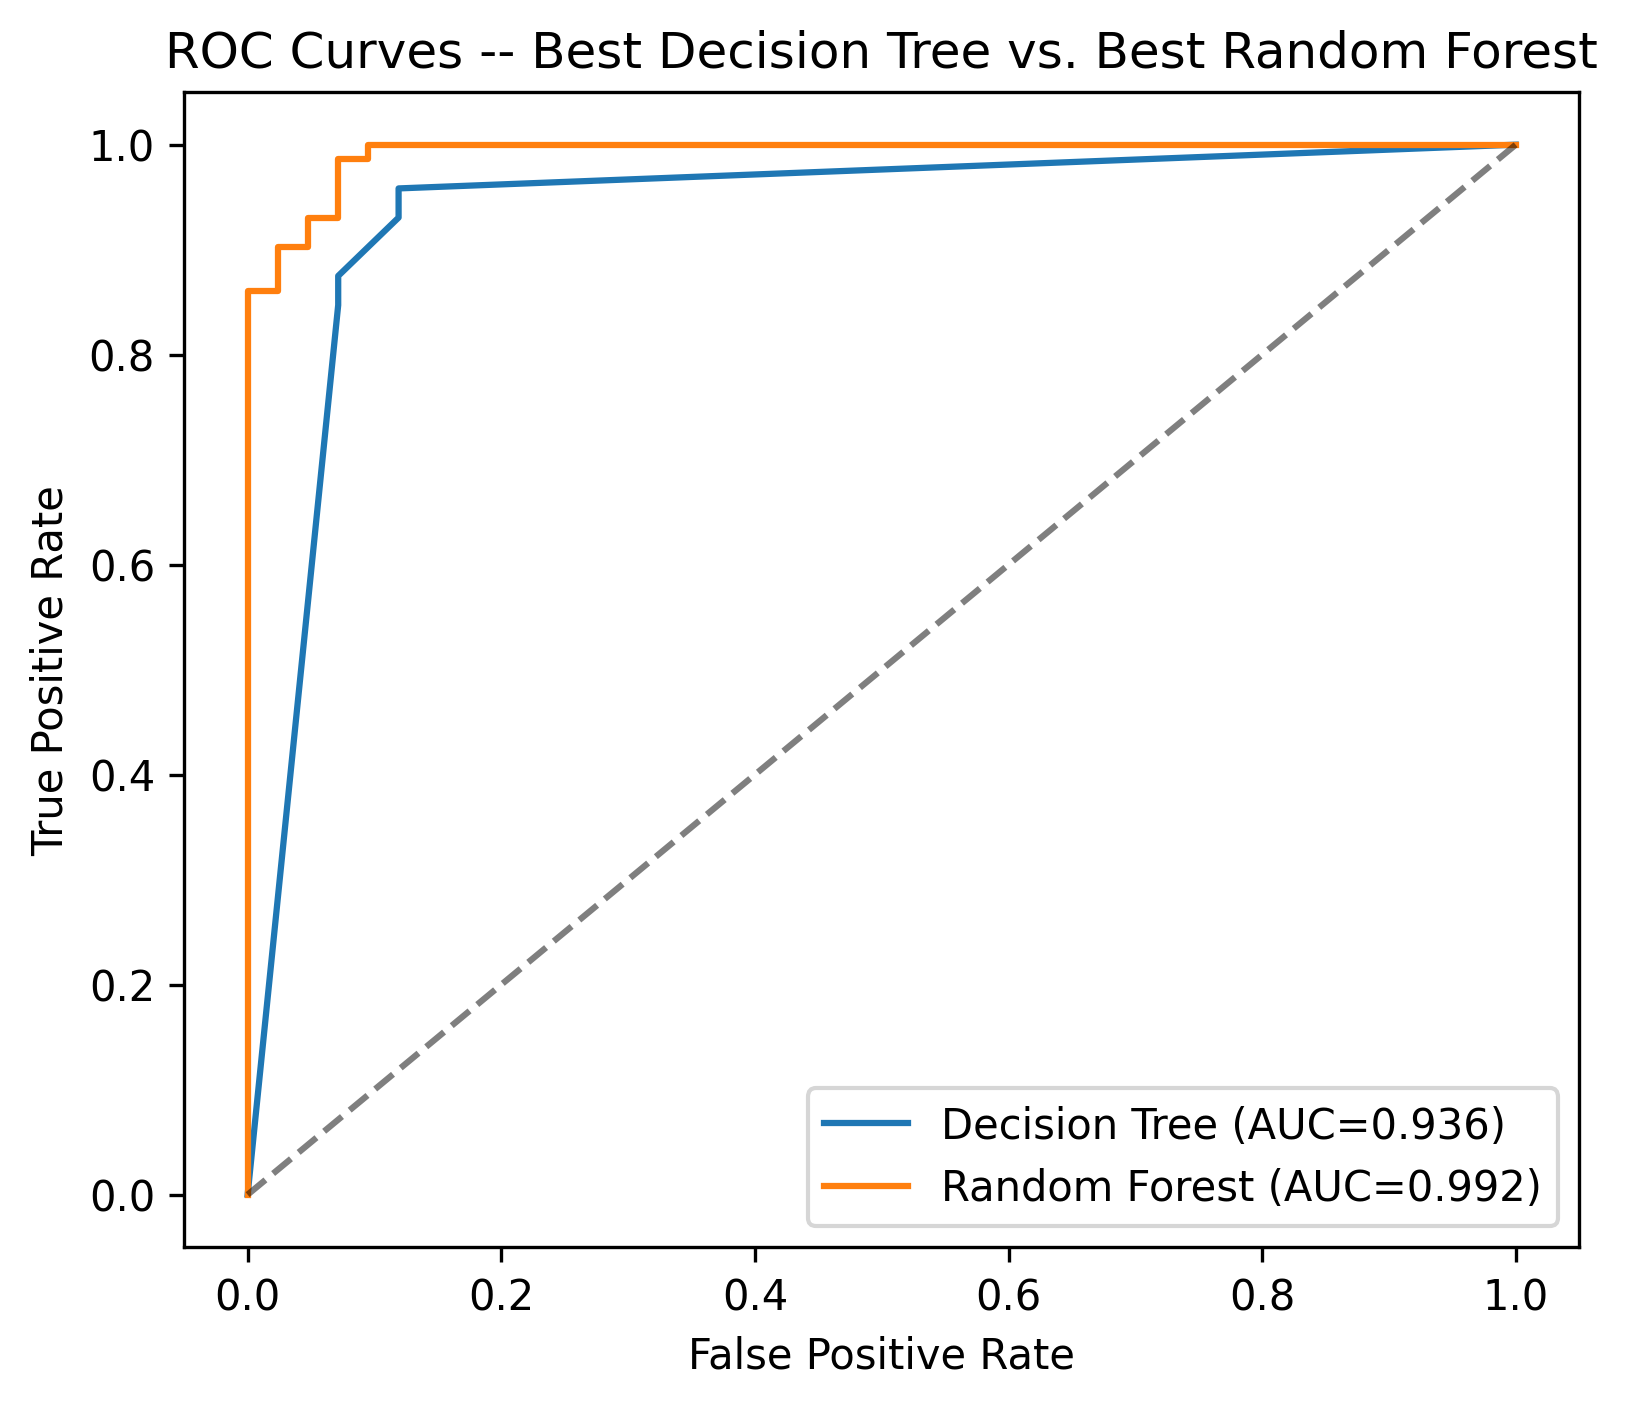

In [18]:
plt.figure(figsize=(6,5))
fpr_dt, tpr_dt, _ = roc_curve(y_test, best_dt_prob)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={roc_auc_score(y_test, best_dt_prob):.3f})")
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf_prob)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, best_rf_prob):.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves -- Best Decision Tree vs. Best Random Forest")
plt.legend()
plt.savefig("exp5_figures/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. Feature Importance Assessment


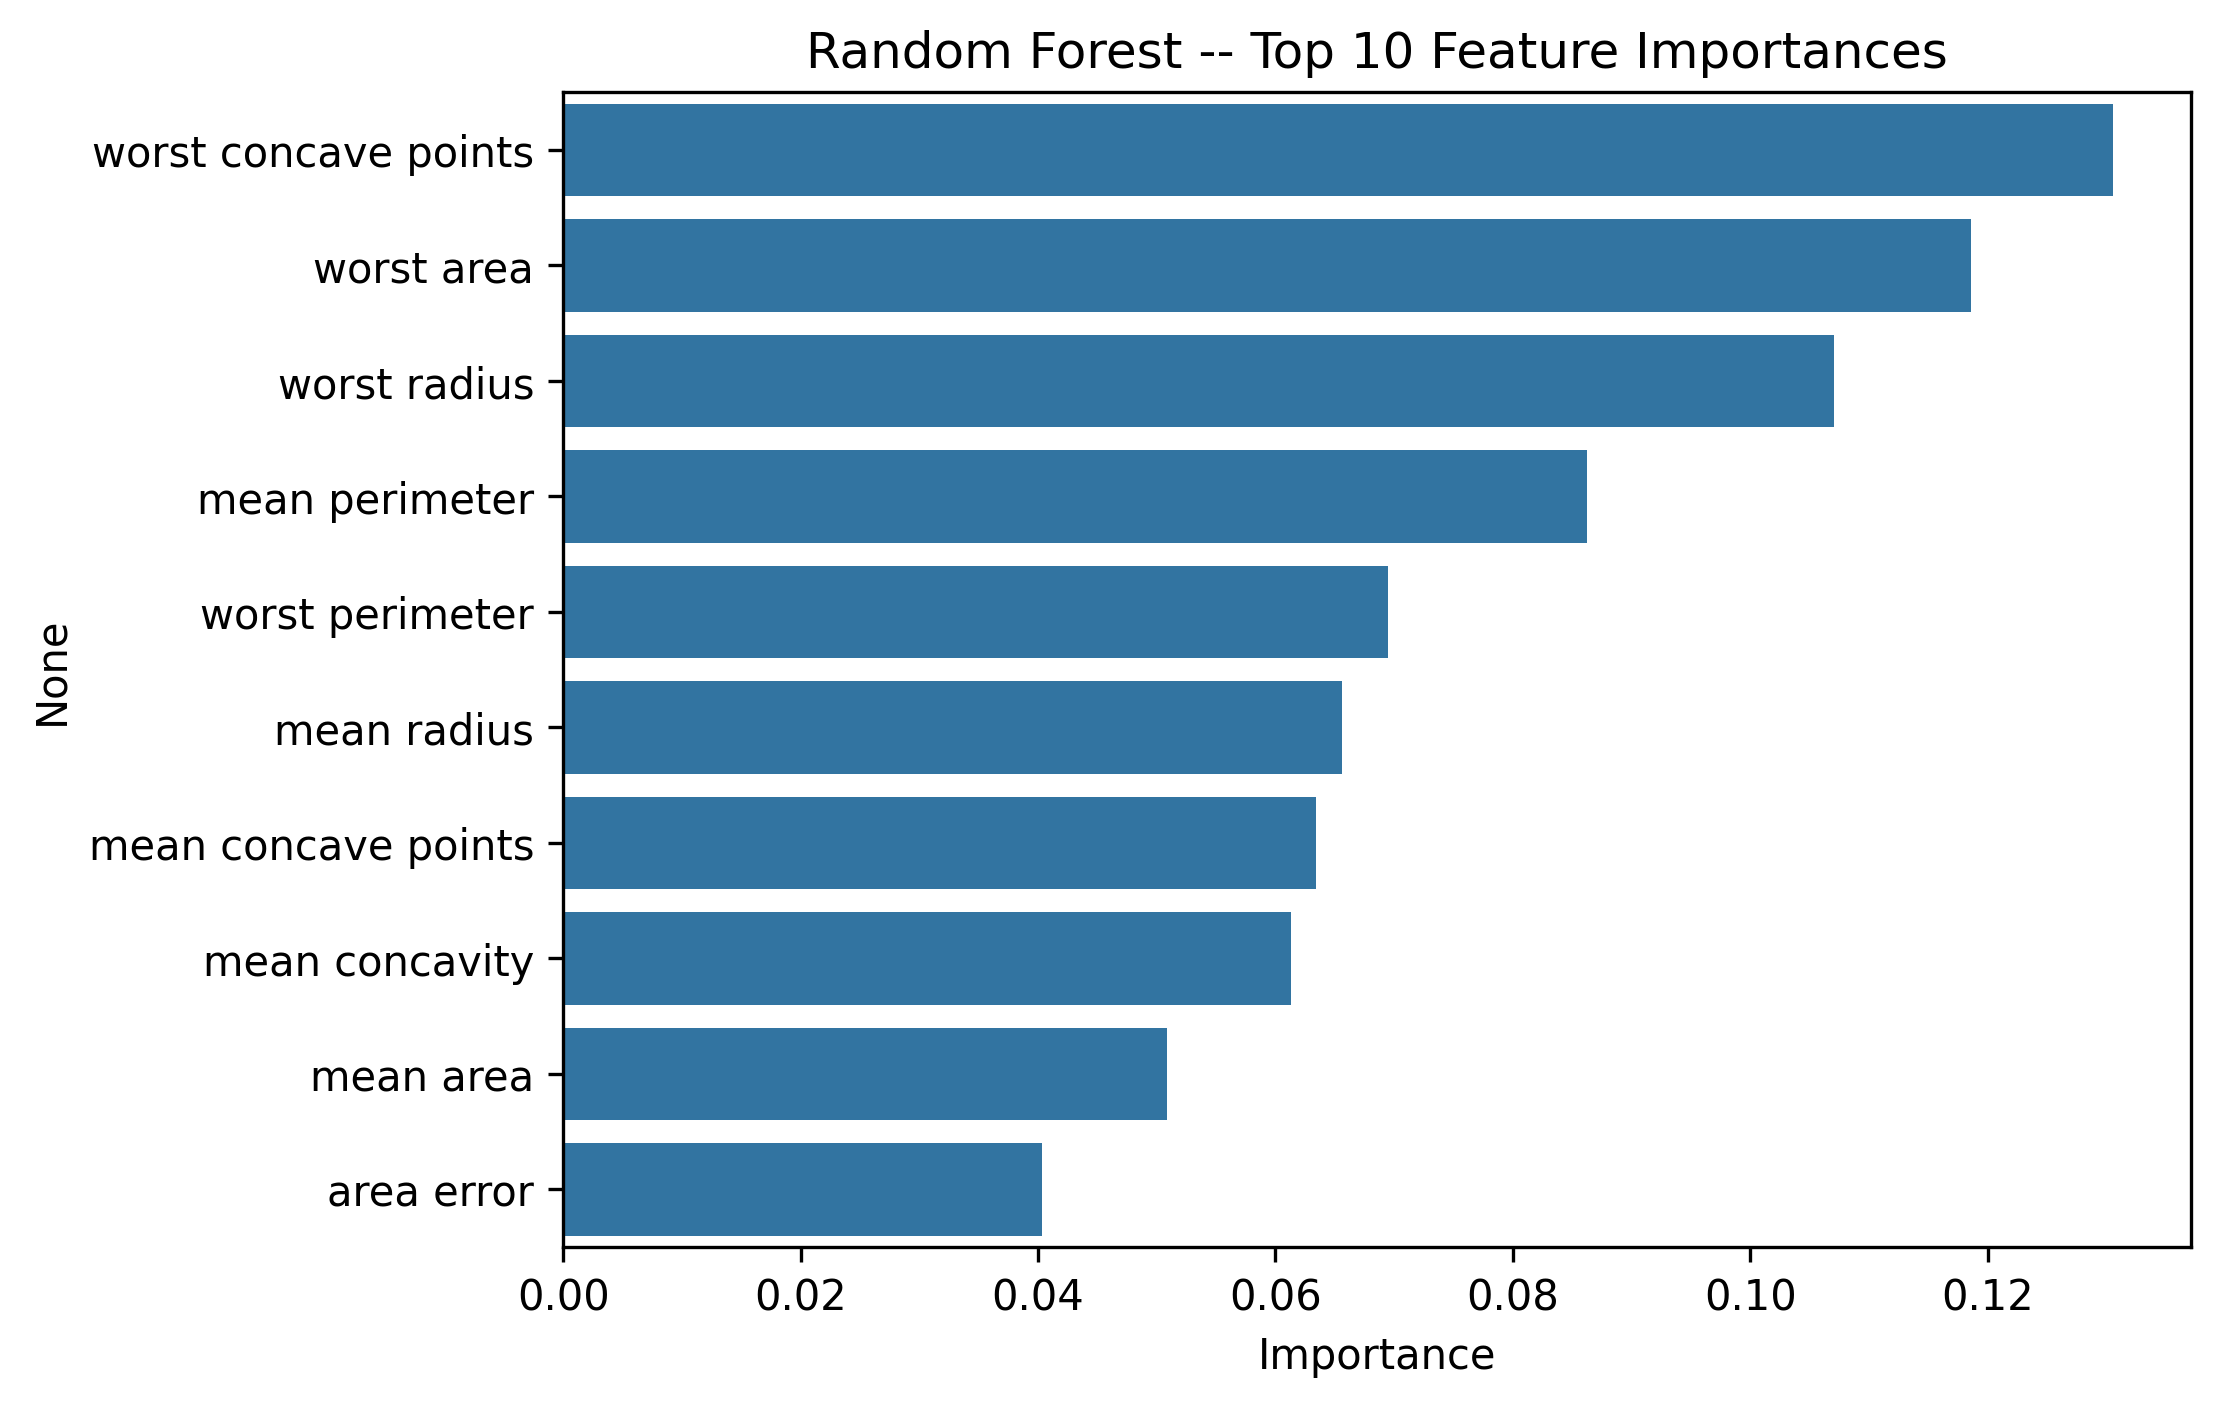

In [19]:
importances = pd.Series(best_forest_model.feature_importances_, index=feat_df.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest -- Top 10 Feature Importances")
plt.xlabel("Importance")
plt.savefig("exp5_figures/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Decision Tree Model Structure Visualization


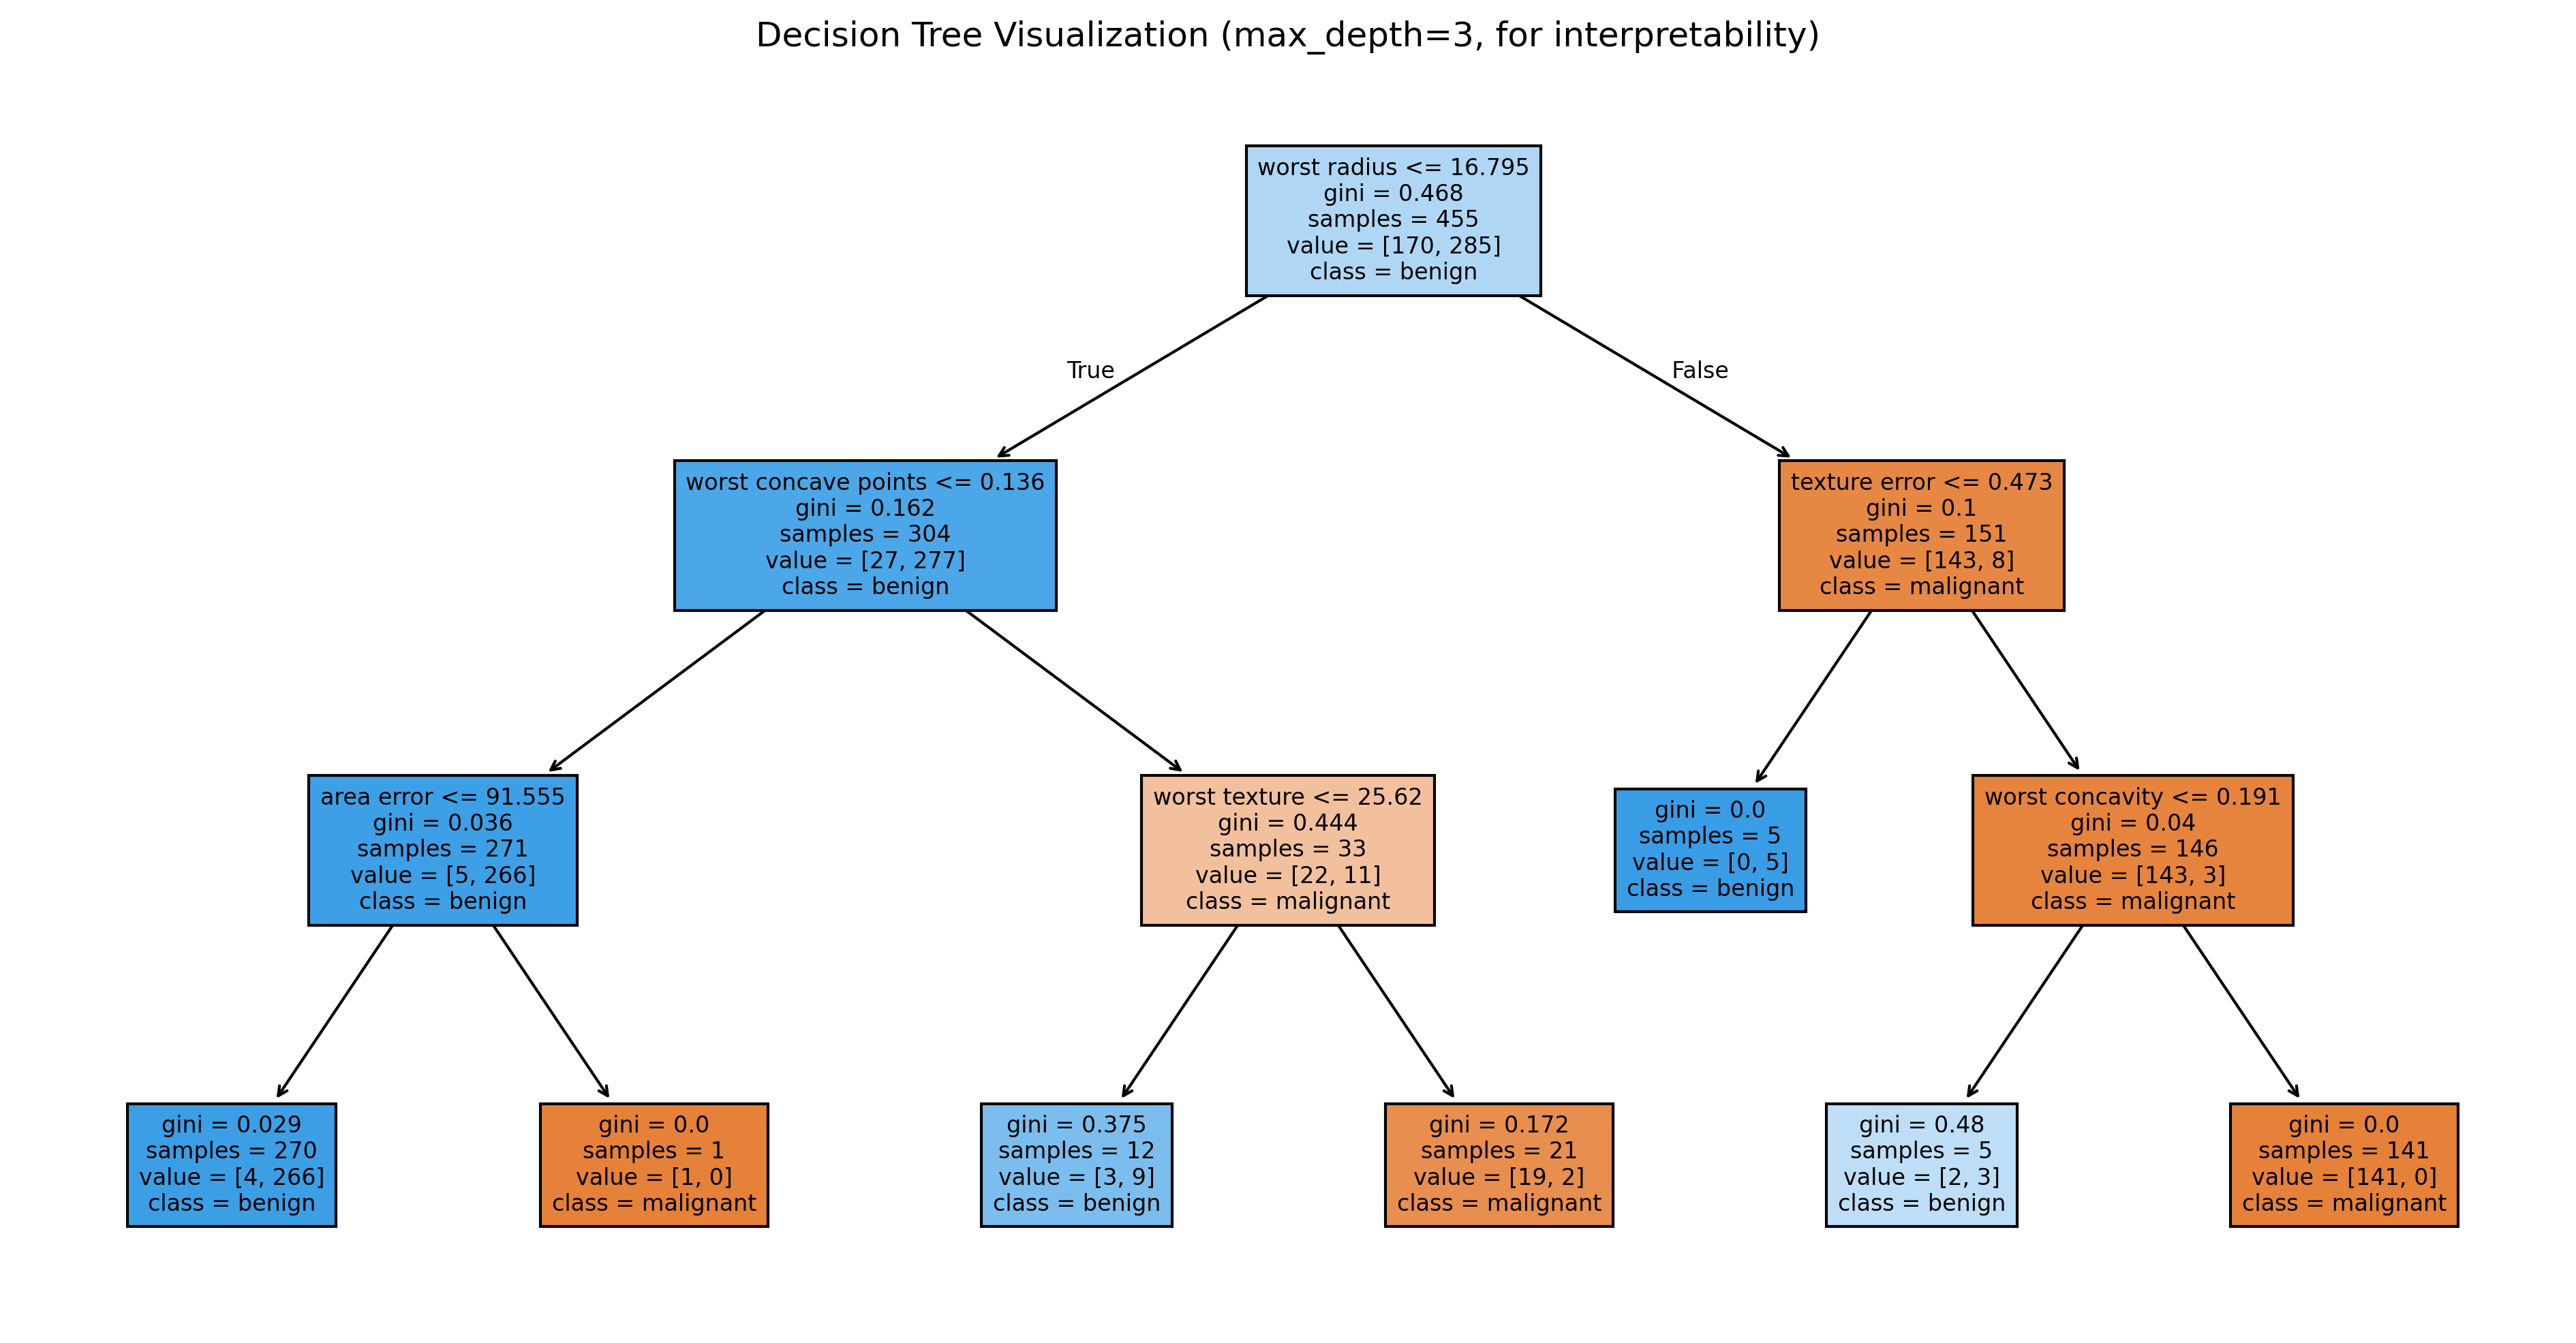

In [20]:
plt.figure(figsize=(16,8))
vis_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_SEED)
vis_tree.fit(X_train, y_train)
plot_tree(vis_tree, feature_names=feat_df.columns, class_names=["malignant","benign"],
          filled=True, fontsize=8)
plt.title("Decision Tree Visualization (max_depth=3, for interpretability)")
plt.savefig("exp5_figures/tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. Comprehensive Metric Comparison Bar Chart


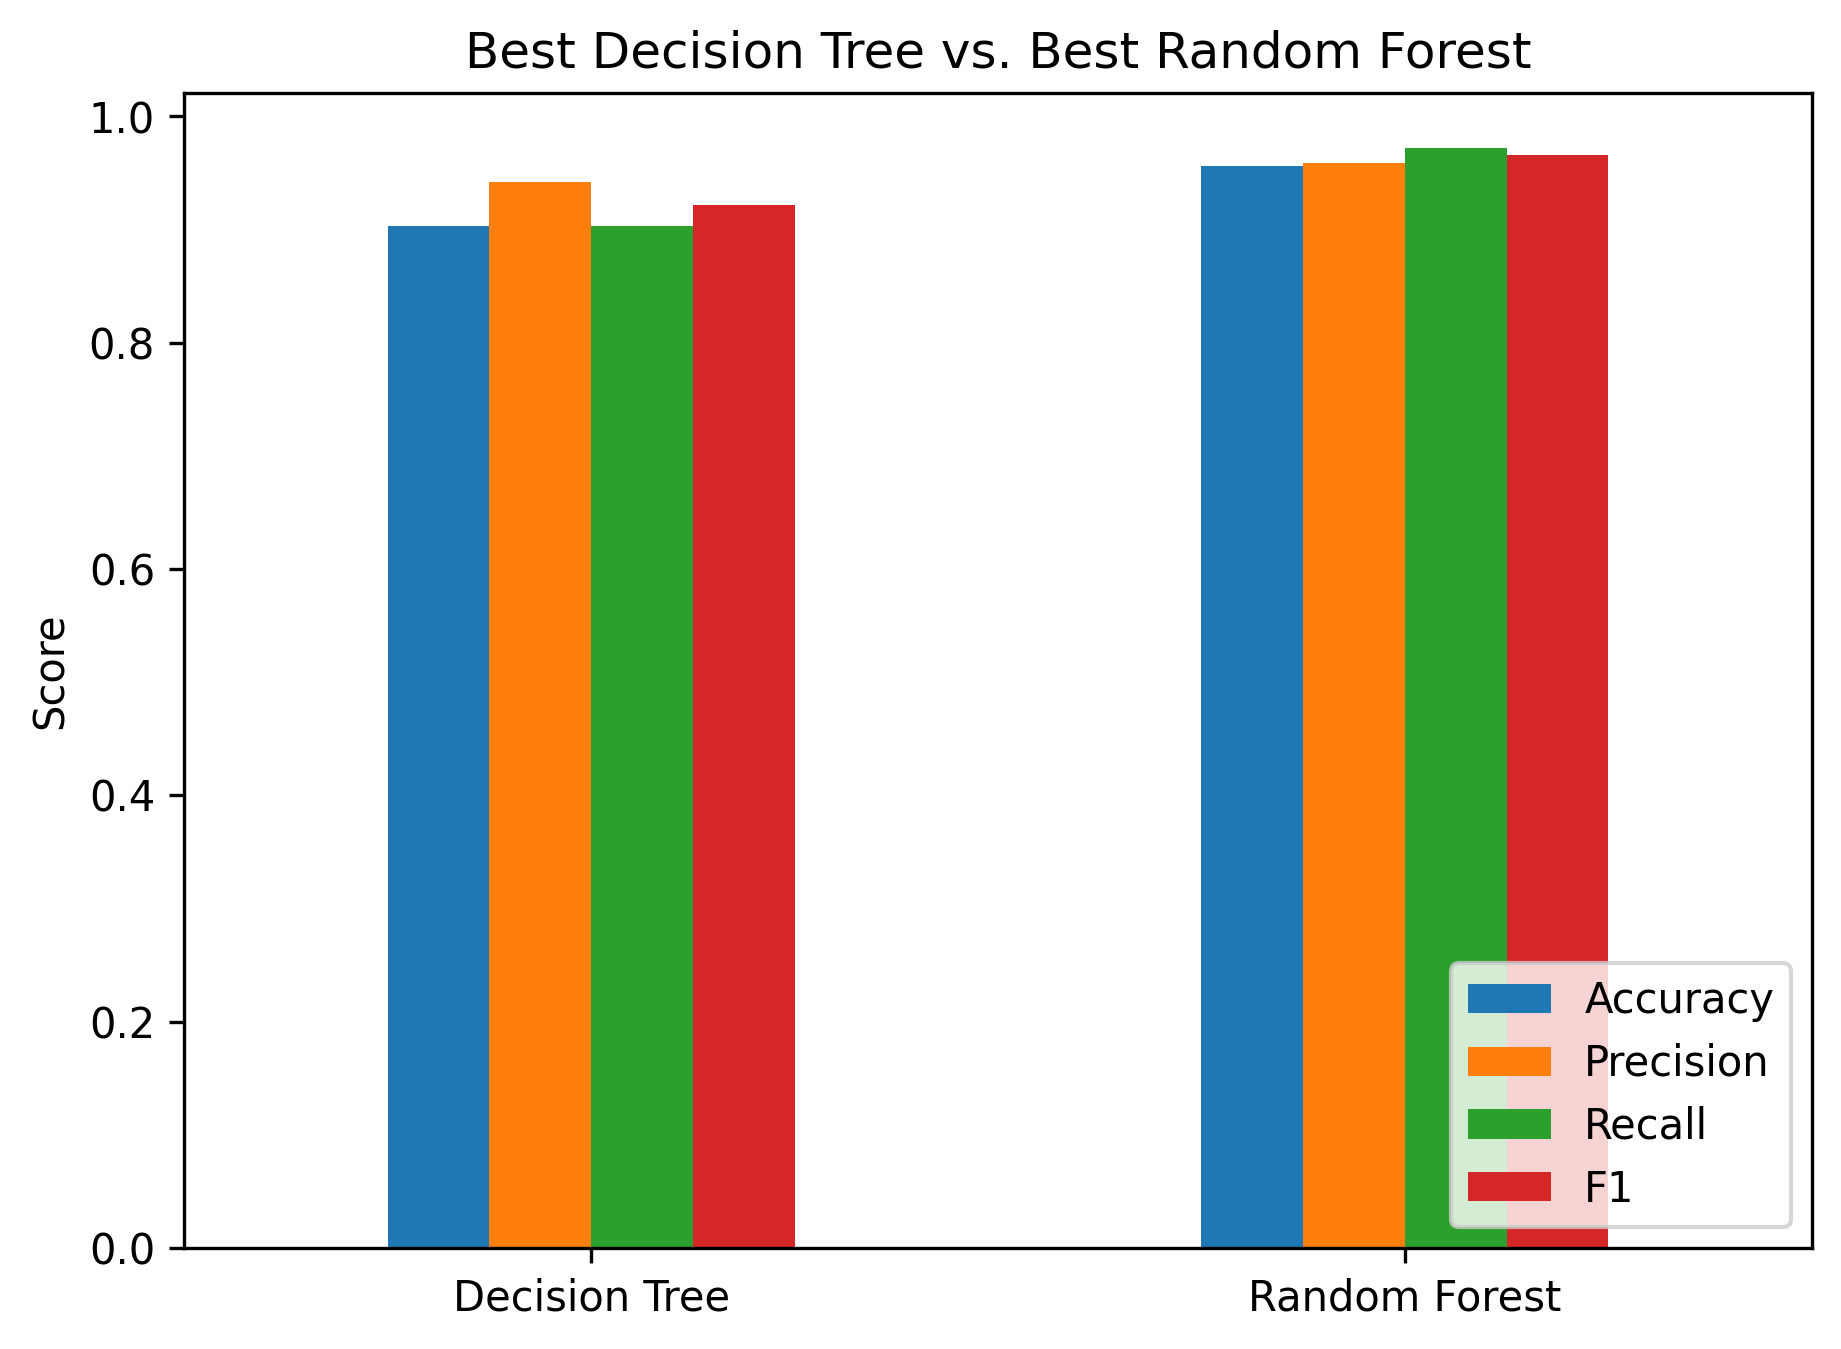

,Accuracy,Precision,Recall,F1
Decision Tree,0.903509,0.942029,0.902778,0.921986
Random Forest,0.956140,0.958904,0.972222,0.965517


In [21]:
comparison_df = pd.DataFrame({
    "Decision Tree": best_dt_stats,
    "Random Forest": best_rf_stats,
}).T[["Accuracy", "Precision", "Recall", "F1"]]

comparison_df.plot(kind="bar", figsize=(7,5))
plt.title("Best Decision Tree vs. Best Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.savefig("exp5_figures/classifier_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
comparison_df


## Summary

See the accompanying report (`Experiment5.pdf`) for full theoretical details, detailed observation responses, and comparative performance analysis grounded in these experimental findings.
